# Bankrupcy Prediction
## Import data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


- Read in the 5 arff files, then merge them together

In [2]:
df1 = pd.read_csv('../data/1year.arff',skiprows=69,header=None,na_values='?')
df2 = pd.read_csv('../data/2year.arff',skiprows=69,header=None,na_values='?')
df3 = pd.read_csv('../data/3year.arff',skiprows=69,header=None,na_values='?')
df4 = pd.read_csv('../data/4year.arff',skiprows=69,header=None,na_values='?')
df5 = pd.read_csv('../data/5year.arff',skiprows=69,header=None,na_values='?')
df1["year"] = 1
df2["year"] = 2
df3["year"] = 3
df4["year"] = 4
df5["year"] = 5
df_final = pd.concat([df1, df2, df3, df4, df5], axis=0)
df_final.head()


,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


In [3]:
new_column_names = [f'X{i+1}' for i in range(64)]
new_column_names.append('Bankrupcy')
new_column_names.append('Year')
df_final.columns = new_column_names
df_final.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X57,X58,X59,X60,X61,X62,X63,X64,Bankrupcy,Year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


## EDA
### Missing values and Imputations

In [4]:
missing = pd.DataFrame(df_final.isnull().sum(), columns=['Missing'])
missing['Percentage'] = (missing['Missing'] / len(df_final)) * 100
missing = missing.sort_values(by='Percentage', ascending=True)
missing

,Missing,Percentage
Year,0,0.000000
Bankrupcy,0,0.000000
X55,1,0.002304
X59,7,0.016127
X57,7,0.016127
...,...,...
X45,2147,4.946435
X60,2152,4.957954
X27,2764,6.367930
X21,5854,13.486925


In [5]:
missing

,Missing,Percentage
Year,0,0.000000
Bankrupcy,0,0.000000
X55,1,0.002304
X59,7,0.016127
X57,7,0.016127
...,...,...
X45,2147,4.946435
X60,2152,4.957954
X27,2764,6.367930
X21,5854,13.486925


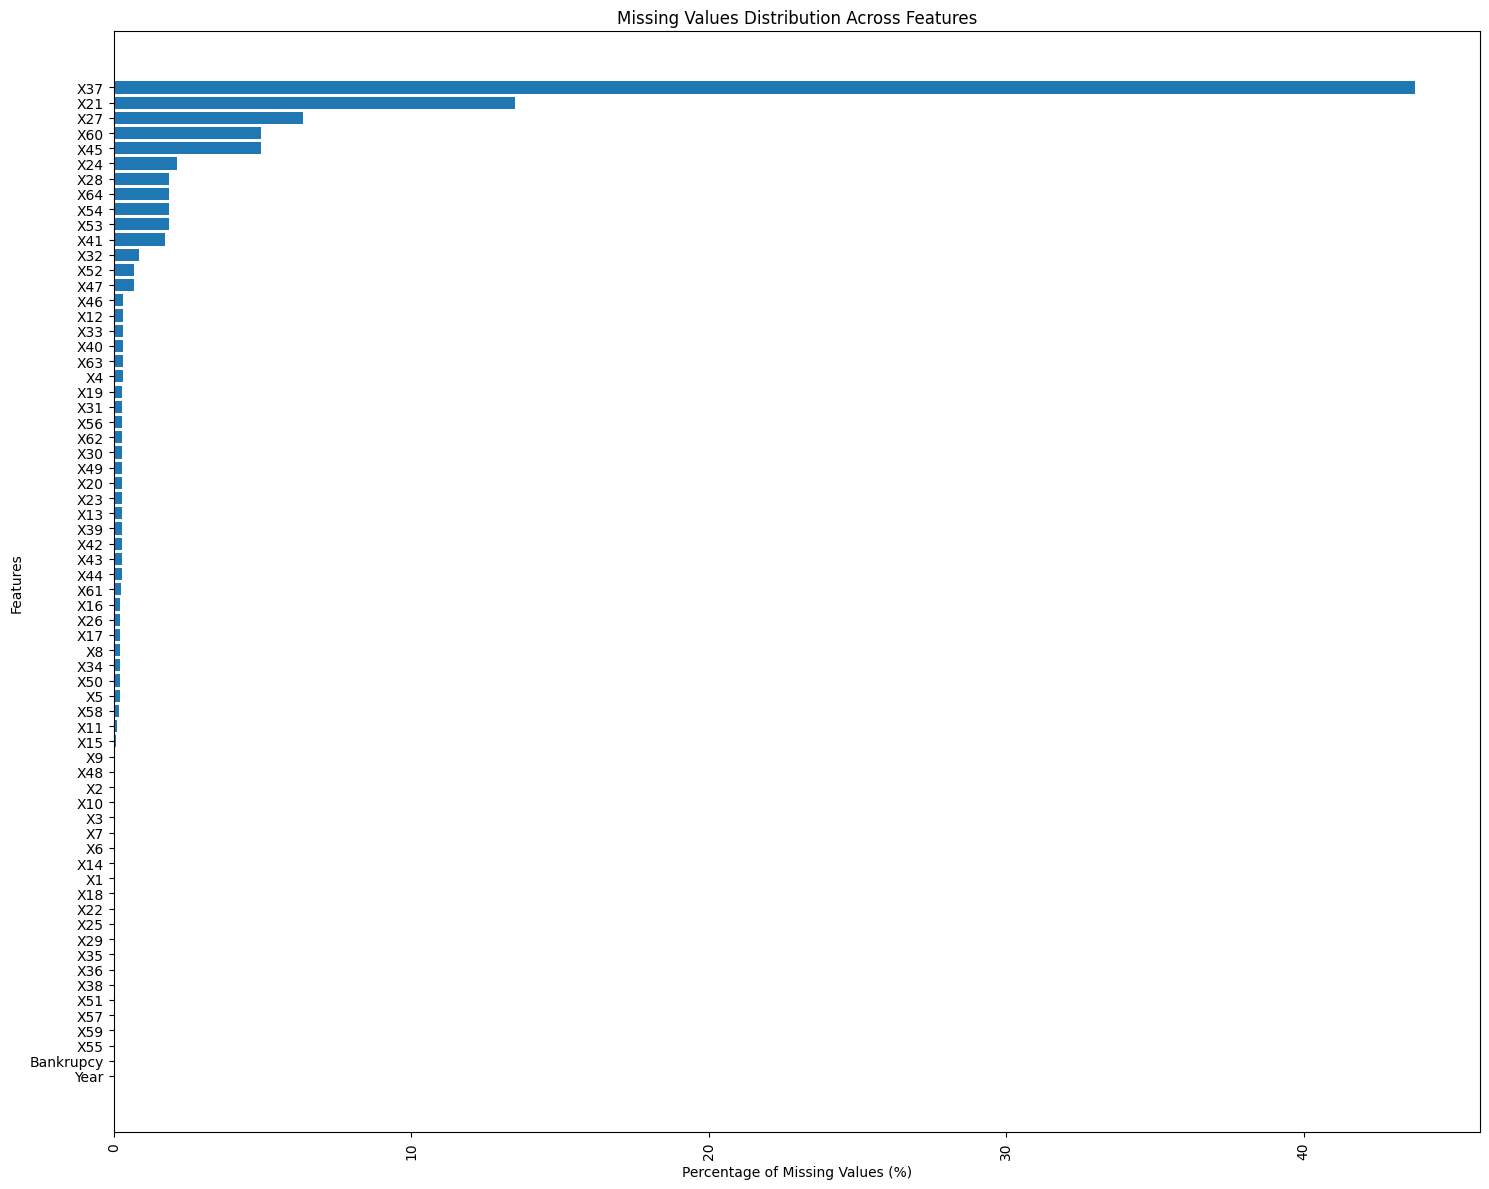

In [6]:
# Create the plot
plt.figure(figsize=(15, 12))
plt.barh(missing.index, missing.Percentage)
plt.xticks(rotation=90)
plt.title('Missing Values Distribution Across Features')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.tight_layout()
# Save the plot
# plt.savefig('../plots/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

- X37 is (current assets - inventories) / long-term liabilities, there are many other related variables to replace X37
- We remove X37
- X21 and X27 are to be remained and imputed with KNNImputer

In [7]:
df_final = df_final.drop(columns=['X37'])

In [8]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights='uniform')
df_imputed = pd.DataFrame(imputer.fit_transform(df_final), columns=df_final.columns)

df_imputed.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X57,X58,X59,X60,X61,X62,X63,X64,Bankrupcy,Year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0.0,1.0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0.0,1.0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0.0,1.0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0.0,1.0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0.0,1.0


### Distribution of Bankrupcy by Year

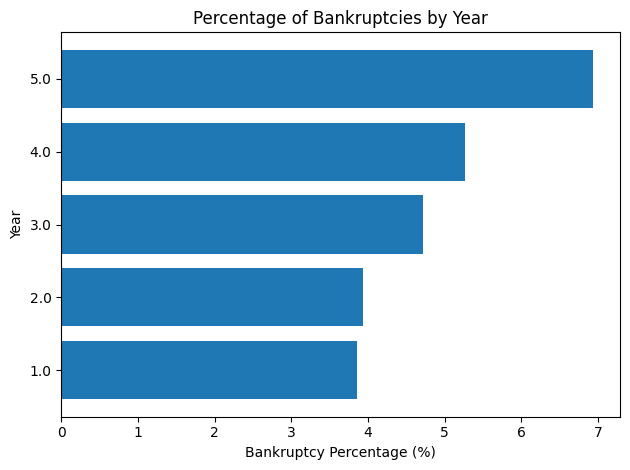

In [9]:
# Step 1: Group by Year and calculate counts
total_per_year = df_imputed.groupby('Year').size()
bankrupt_per_year = df_imputed[df_imputed['Bankrupcy'] == 1].groupby('Year').size()

# Step 2: Calculate percentage
percent_bankruptcy = (bankrupt_per_year / total_per_year * 100).fillna(0).sort_index()

# Step 3: Plot
plt.barh(percent_bankruptcy.index.astype(str), percent_bankruptcy.values)
plt.xlabel('Bankruptcy Percentage (%)')
plt.ylabel('Year')
plt.title('Percentage of Bankruptcies by Year')
plt.tight_layout()
plt.show()


### Cross Correlation Analysis

In [10]:
X = df_imputed.iloc[:, :-2]
y = df_imputed.iloc[:, -2]

- Calculate the cross correlation between 64 features
- Sort list the strong correlation pairs with R>0.95
- Print out the top 20 highest pairs

In [11]:
corr_matrix = X.corr().abs()

# Unstack to long format
corr_pairs = corr_matrix.unstack()

# Remove self-correlations and duplicate pairs
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()

# Filter strong correlations
strong_corr = corr_pairs[corr_pairs > 0.95].sort_values(ascending=False)
print(strong_corr.head(20))

X7   X14    1.000000
X4   X46    0.999923
X20  X56    0.999878
X8   X17    0.999609
X19  X23    0.999291
     X31    0.999200
X43  X44    0.999021
X10  X38    0.998974
X53  X54    0.998750
X23  X31    0.998490
X56  X58    0.998202
X20  X58    0.998191
X3   X51    0.998160
X14  X18    0.995777
X7   X18    0.995759
X9   X36    0.995228
X43  X56    0.991564
X20  X43    0.991523
X16  X26    0.991151
X43  X58    0.989796
dtype: float64


In [12]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import fcluster    

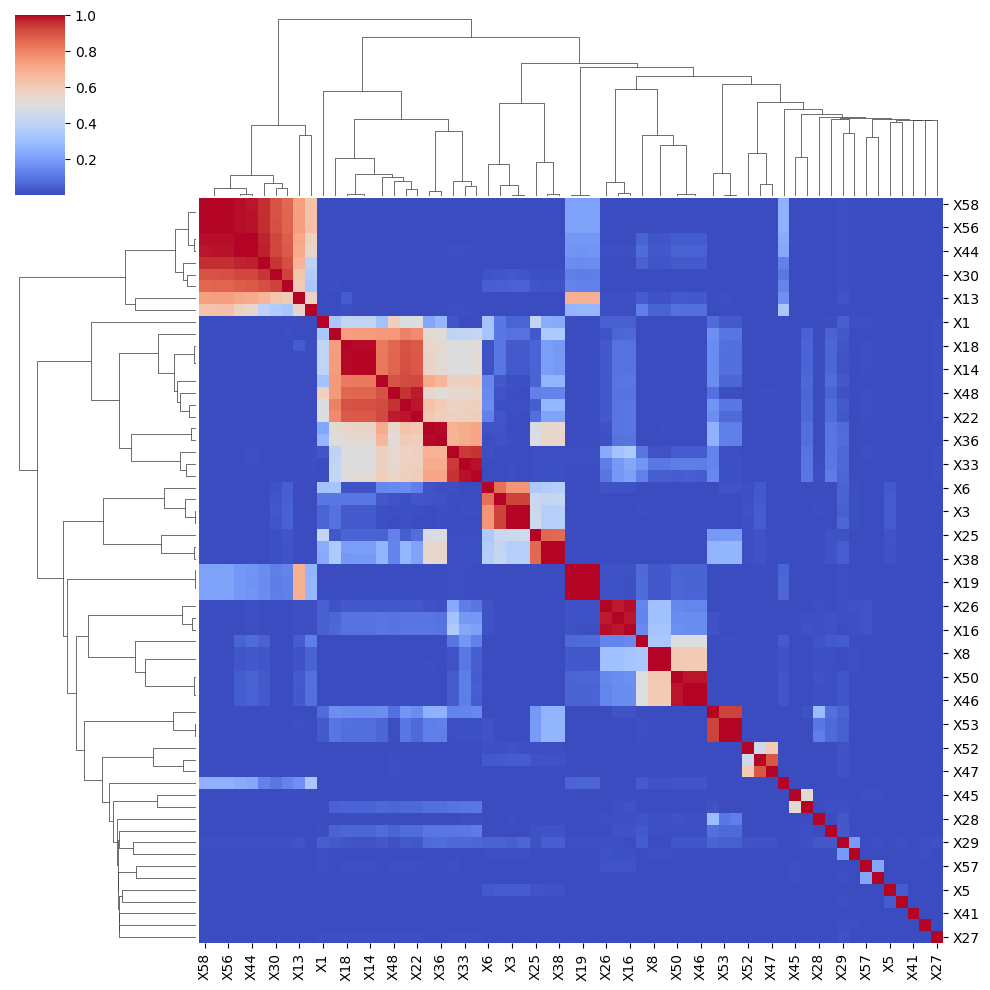

In [13]:
# Perform clustering manually and pass linkage to clustermap
linkage = sch.linkage(pdist(corr_matrix), method='average')
g = sns.clustermap(corr_matrix, row_linkage=linkage, col_linkage=linkage, cmap="coolwarm")

In [14]:
# Define number of clusters (e.g. 5)
cluster_labels = fcluster(linkage, t=8, criterion='maxclust')

# Map feature names to cluster labels
feature_names = corr_matrix.columns[g.dendrogram_col.reordered_ind]
cluster_map = pd.Series(cluster_labels, index=feature_names)

# Get top cluster (most frequent cluster ID)
top_cluster_id = cluster_map.value_counts().idxmax()
top_cluster_features = cluster_map[cluster_map == top_cluster_id].index.tolist()

print("Top cluster ID:", top_cluster_id)
print("Top cluster features:", top_cluster_features)


Top cluster ID: 8
Top cluster features: ['X44', 'X14', 'X36', 'X3', 'X51', 'X25', 'X31', 'X40', 'X17', 'X64', 'X54', 'X45', 'X61', 'X55', 'X59', 'X5', 'X15']


In [15]:
len(top_cluster_features)

17

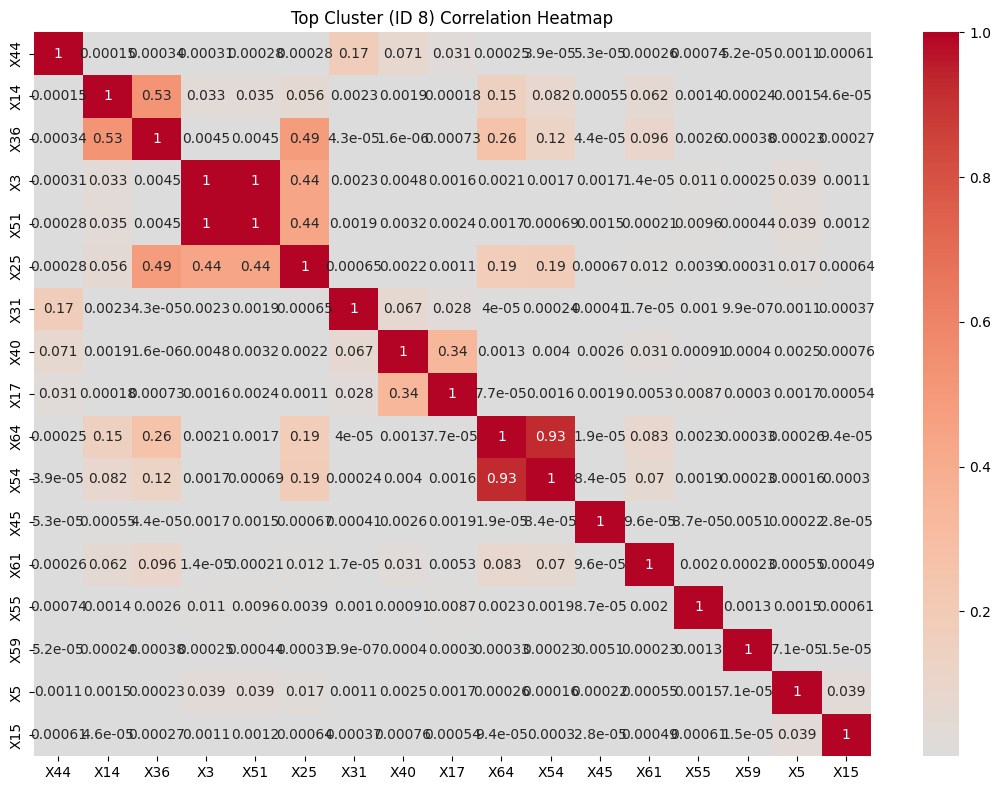

In [16]:
# Subset correlation matrix to only features in top cluster
corr_top = corr_matrix.loc[top_cluster_features, top_cluster_features]

# Plot heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(corr_top, annot=True, cmap='coolwarm', center=0)
plt.title(f"Top Cluster (ID {top_cluster_id}) Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
X_selected = X[corr_top.index]
X_selected = X_selected.drop(columns=['X51','X54'])
X_selected.head()

,X44,X14,X36,X3,X25,X31,X40,X17,X64,X45,X61,X55,X59,X5,X15
0,71.050,0.249760,1.7410,0.39641,0.50494,0.149420,0.662950,2.6349,7.4277,1.00970,5.1372,348690.0,0.001924,32.3510,497.42
1,111.510,0.258340,1.6996,0.47225,0.39542,0.152000,0.086422,2.0005,60.9870,0.51045,3.2732,2304.6,0.000000,14.7860,677.96
2,92.381,0.309060,1.3090,0.26713,0.28932,0.238150,0.322020,1.4369,5.2078,0.94807,3.9510,6332.7,0.694840,-1.1523,794.16
3,100.980,0.092704,1.3562,0.45879,0.57353,0.071428,0.401390,3.2537,5.5497,0.28720,3.6147,20545.0,0.000000,51.9520,917.01
4,84.574,0.187320,1.6278,0.22960,0.38677,0.115530,0.293040,1.6307,7.8980,0.73919,4.3158,3186.6,0.124440,-7.3128,1133.20


### VIF


In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant (intercept) for VIF calculation
X1 = add_constant(X_selected)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X1.columns
vif_data['VIF'] = [variance_inflation_factor(X1.values, i)
                   for i in range(X1.shape[1])]

# Drop constant row if desired
vif_data = vif_data[vif_data['Feature'] != 'const']

print(vif_data)

   Feature       VIF
1      X44  1.038263
2      X14  1.893745
3      X36  2.694093
4       X3  1.515944
5      X25  2.432818
6      X31  1.037678
7      X40  1.141406
8      X17  1.129651
9      X64  1.089993
10     X45  1.000038
11     X61  1.016953
12     X55  1.000234
13     X59  1.000028
14      X5  1.003041
15     X15  1.001528


## Modeling with RF
RF and XGBoost are tree-based model hence does not really require feature selection


In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=123)
X_selected_train,X_selected_test,y_selected_train,y_selected_test = train_test_split(X_selected,y,train_size=0.8,random_state=123)

### Modeling RF1: Using entire data

In [22]:
%%time
from sklearn.model_selection import GridSearchCV
# Define parameter grid
rf = RandomForestClassifier(n_estimators=25,random_state=123)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_features': [5,10,15,20],
    'max_depth': [None, 1,3,5,7,9],
    'min_samples_split': [8,6,4],
    'min_samples_leaf': [4,2,1],
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit to your data
grid_search.fit(X_train, y_train)

# Best model and parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 20, 'min_samples_leaf': 2, 'min_samples_split': 8}
Best Score: 0.9582421585996622
CPU times: user 25.5 s, sys: 1.73 s, total: 27.2 s
Wall time: 6min


In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=123)

model_rf_all = RandomForestClassifier(n_estimators=100,random_state=123)
model_rf_all.fit(X_train,y_train)

y_pred_rf_full = model_rf_all.predict(X_test)

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      8285
         1.0       0.56      0.07      0.12       396

    accuracy                           0.96      8681
   macro avg       0.76      0.53      0.55      8681
weighted avg       0.94      0.96      0.94      8681

[[8264   21]
 [ 369   27]]
0.95507430019583


### Modeling RF2: Using selected data

In [24]:
%%time
# Grid search with 5-fold cross-validation
grid_search_rf2 = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit to your data
grid_search_rf2.fit(X_selected_train, y_selected_train)

# Best model and parameters
print("Best Parameters:", grid_search_rf2.best_params_)
print("Best Score:", grid_search_rf2.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'max_features': 10, 'min_samples_leaf': 2, 'min_samples_split': 8}
Best Score: 0.9513592935606627
CPU times: user 12.3 s, sys: 1.22 s, total: 13.5 s
Wall time: 5min 17s


In [25]:

model_rf_selected = RandomForestClassifier(n_estimators=100,random_state=123)
model_rf_selected.fit(X_selected_train,y_selected_train)

y_pred2 = model_rf_selected.predict(X_selected_test)

print(classification_report(y_selected_test,y_pred2))
print(confusion_matrix(y_selected_test,y_pred2))
print(accuracy_score(y_selected_test,y_pred2))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      8285
         1.0       0.05      0.01      0.01       396

    accuracy                           0.95      8681
   macro avg       0.50      0.50      0.49      8681
weighted avg       0.91      0.95      0.93      8681

[[8230   55]
 [ 393    3]]
0.9483930422762354


### Find the optimal hyperparameters

### Important variables
- Plot 2 figures for feature importances for full and selected data

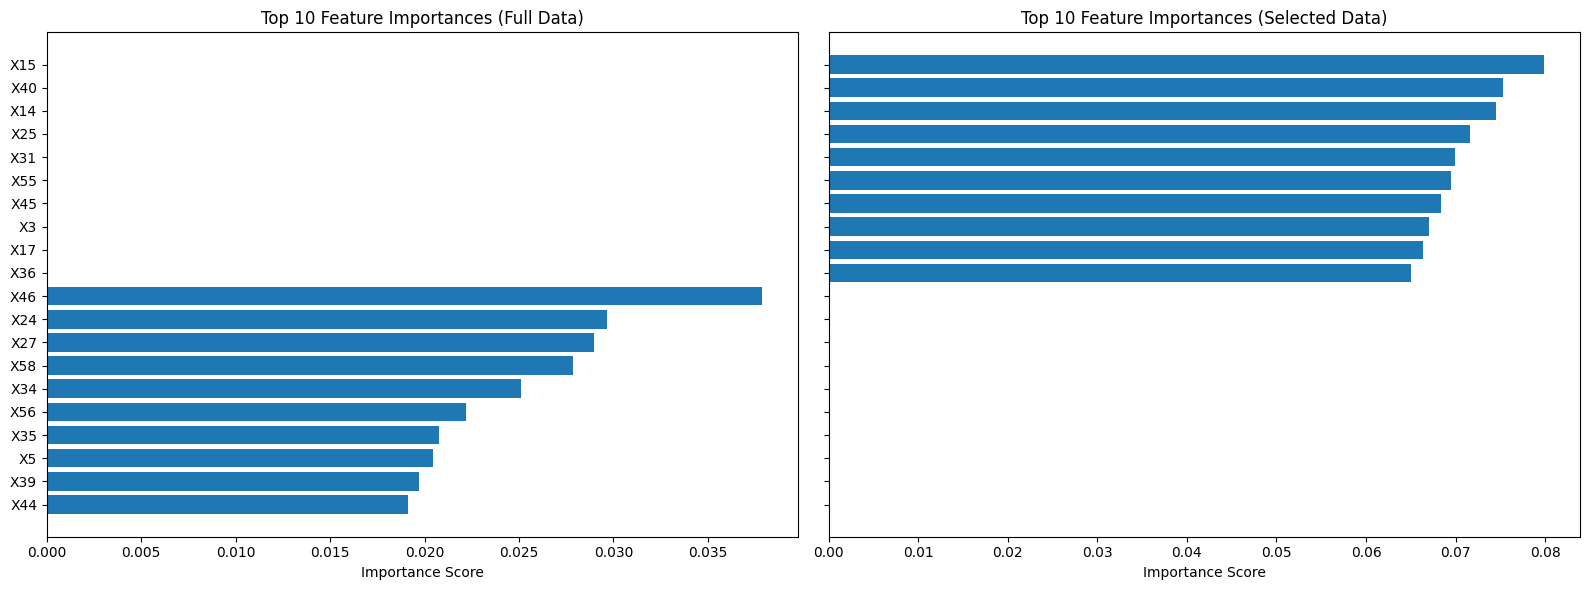

In [26]:
# Get feature importances
importances_selected  = model_rf_selected.feature_importances_
features = X_selected_train.columns
importances_full = model_rf_all.feature_importances_
features_full = X_train.columns 

# Display top features
importance_df_selected = pd.DataFrame({'Feature': features, 'Importance': importances_selected})
importance_df_selected.sort_values(by='Importance', ascending=False, inplace=True)

importance_df_full = pd.DataFrame({'Feature': features_full, 'Importance': importances_full})
importance_df_full.sort_values(by='Importance', ascending=False, inplace=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Full feature importance
axes[0].barh(
    importance_df_full['Feature'].iloc[:10][::-1],
    importance_df_full['Importance'].iloc[:10][::-1]
)
axes[0].set_title("Top 10 Feature Importances (Full Data)")
axes[0].set_xlabel("Importance Score")

# Selected feature importance
axes[1].barh(
    importance_df_selected['Feature'].iloc[:10][::-1],
    importance_df_selected['Importance'].iloc[:10][::-1]
)
axes[1].set_title("Top 10 Feature Importances (Selected Data)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


### XGBoost model - All data
- Cross Validation

In [27]:
params = {
    'subsample': 0.75,
    'max_depth': 4,
    'eval_metric': 'auc',
    'objective': 'binary:logistic'
}

def XGBRandomSearch(params, data, n_iter=30):
    best_score = 0
    best_params = 'error'

    max_d = np.random.choice([2, 4, 6, 8, 10, 12, 15, 20], n_iter)
    subs = 0.5 + np.random.random(n_iter) / 2
    colsample_bytree = 0.5 + np.random.random(n_iter) / 2
    colsample_bylevel = 0.5 + np.random.random(n_iter) / 2
    colsample_bynode = 0.5 + np.random.random(n_iter) / 2

    for i in range(n_iter):
        params['subsample'] = subs[i]
        params['max_depth'] = max_d[i]
        params['colsample_bytree'] = colsample_bytree[i]
        params['colsample_bylevel'] = colsample_bylevel[i]
        params['colsample_bynode'] = colsample_bynode[i]

        f = xgb.cv(
            params, 
            dtrain=data, 
            nfold=5,
            stratified=True, 
            metrics='auc',
            num_boost_round=1000, 
            early_stopping_rounds=10
        )

        if f.shape[0] == 1000:
            print("Warning hit limit")
        print(params, f['test-auc-mean'].max())

        if f['test-auc-mean'].max() > best_score:
            best_score = f['test-auc-mean'].max()
            best_params = copy.deepcopy(params)

    return f, best_score, best_params


In [28]:
traindata = xgb.DMatrix(X_train, label=y_train)
testdata = xgb.DMatrix(X_test, label=y_test)

In [29]:
%%time
b = xgb.train(params,evals=[(traindata,'train'),(testdata,'test')],num_boost_round=1000,dtrain=traindata,early_stopping_rounds=10)

[0]	train-auc:0.77346	test-auc:0.74402
[1]	train-auc:0.79488	test-auc:0.76707
[2]	train-auc:0.80419	test-auc:0.77930
[3]	train-auc:0.82998	test-auc:0.80348
[4]	train-auc:0.84099	test-auc:0.80988
[5]	train-auc:0.84831	test-auc:0.81260
[6]	train-auc:0.85693	test-auc:0.82317
[7]	train-auc:0.85693	test-auc:0.82155
[8]	train-auc:0.86491	test-auc:0.83029
[9]	train-auc:0.87085	test-auc:0.83847
[10]	train-auc:0.88055	test-auc:0.85022
[11]	train-auc:0.88851	test-auc:0.85713
[12]	train-auc:0.89331	test-auc:0.86225
[13]	train-auc:0.90014	test-auc:0.87325
[14]	train-auc:0.90574	test-auc:0.87882
[15]	train-auc:0.91018	test-auc:0.88311
[16]	train-auc:0.91333	test-auc:0.88549
[17]	train-auc:0.91607	test-auc:0.88807
[18]	train-auc:0.91885	test-auc:0.88864
[19]	train-auc:0.92023	test-auc:0.88920
[20]	train-auc:0.92205	test-auc:0.88977
[21]	train-auc:0.92532	test-auc:0.89277
[22]	train-auc:0.92844	test-auc:0.89557
[23]	train-auc:0.92991	test-auc:0.89585
[24]	train-auc:0.93640	test-auc:0.90067
[25]	train

In [30]:
%%time 
result = XGBRandomSearch(params,traindata,n_iter=30)

{'subsample': 0.9849140019698497, 'max_depth': 20, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.5939185178356372, 'colsample_bylevel': 0.6240925887932987, 'colsample_bynode': 0.623080447309478} 0.9450575930272995
{'subsample': 0.6737275067322246, 'max_depth': 15, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.8595510526851826, 'colsample_bylevel': 0.8751467797120593, 'colsample_bynode': 0.6786205009413164} 0.938294182060333
{'subsample': 0.7355110399806033, 'max_depth': 12, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.8912971127690165, 'colsample_bylevel': 0.6628028253683611, 'colsample_bynode': 0.7430786573458059} 0.9437921189014725
{'subsample': 0.7240812536153072, 'max_depth': 4, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.905645188452515, 'colsample_bylevel': 0.7288332211098147, 'colsample_bynode': 0.7319531639977572} 0.9277596982662478
{'subsample': 0.66742379

In [31]:
result

(     train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
 0          0.795121       0.006812       0.754227      0.016118
 1          0.857260       0.012607       0.785829      0.012482
 2          0.890048       0.011890       0.802089      0.016046
 3          0.926144       0.005612       0.828054      0.011691
 4          0.941919       0.006533       0.841270      0.014232
 ..              ...            ...            ...           ...
 126        1.000000       0.000000       0.934419      0.004446
 127        1.000000       0.000000       0.934458      0.004438
 128        1.000000       0.000000       0.934535      0.004408
 129        1.000000       0.000000       0.934509      0.004318
 130        1.000000       0.000000       0.934586      0.004371
 
 [131 rows x 4 columns],
 0.9488448962383369,
 {'subsample': 0.9810210273543551,
  'max_depth': 15,
  'eval_metric': 'auc',
  'objective': 'binary:logistic',
  'colsample_bytree': 0.8491714220797353,
  'colsample_bylev

In [32]:
%%time

# Train XGBoost classifier
model_xgb = xgb.XGBClassifier(
    use_label_encoder=False,  # suppress label encoder warning
    eval_metric='auc',    # standard metric for classification
    n_estimators=100,         # number of trees
    max_depth=15,              # tree depth
    learning_rate=0.1,        # step size shrinkage
    random_state=123           # for reproducibility
)

model_xgb.fit(X_train, y_train)

# Make predictions
y_pred = model_xgb.predict(X_test)

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))


/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      8285
         1.0       0.89      0.36      0.52       396

    accuracy                           0.97      8681
   macro avg       0.93      0.68      0.75      8681
weighted avg       0.97      0.97      0.96      8681

[[8267   18]
 [ 252  144]]
0.9688975924432669
CPU times: user 1min 56s, sys: 1.01 s, total: 1min 57s
Wall time: 3.29 s


## XGBoost
### Selected data

In [33]:
traindata_selected = xgb.DMatrix(X_selected_train, label=y_selected_train)
testdata_selected = xgb.DMatrix(X_selected_test, label=y_selected_test)

In [34]:
%%time 
b = xgb.train(params,evals=[(traindata_selected,'train'),(testdata_selected,'test')],num_boost_round=1000,dtrain=traindata_selected,early_stopping_rounds=10)

[0]	train-auc:0.75414	test-auc:0.72629
[1]	train-auc:0.78393	test-auc:0.73028
[2]	train-auc:0.80688	test-auc:0.73291
[3]	train-auc:0.83002	test-auc:0.73076
[4]	train-auc:0.84965	test-auc:0.72987
[5]	train-auc:0.87177	test-auc:0.73066
[6]	train-auc:0.89222	test-auc:0.73191
[7]	train-auc:0.91196	test-auc:0.72976
[8]	train-auc:0.92851	test-auc:0.73061
[9]	train-auc:0.93533	test-auc:0.73195
[10]	train-auc:0.94488	test-auc:0.73096
[11]	train-auc:0.95446	test-auc:0.73230
[12]	train-auc:0.95968	test-auc:0.73571
[13]	train-auc:0.96652	test-auc:0.73677
[14]	train-auc:0.97222	test-auc:0.73977
[15]	train-auc:0.97505	test-auc:0.74172
[16]	train-auc:0.97745	test-auc:0.74274
[17]	train-auc:0.97903	test-auc:0.74511
[18]	train-auc:0.98206	test-auc:0.74074
[19]	train-auc:0.98523	test-auc:0.74303
[20]	train-auc:0.98868	test-auc:0.74272
[21]	train-auc:0.98936	test-auc:0.74512
[22]	train-auc:0.99060	test-auc:0.74535
[23]	train-auc:0.99156	test-auc:0.74766
[24]	train-auc:0.99243	test-auc:0.75090
[25]	train

In [35]:
%%time
result = XGBRandomSearch(params,traindata_selected,n_iter=30)

{'subsample': 0.5435646498507704, 'max_depth': 10, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.8353189348090797, 'colsample_bylevel': 0.5195938961271603, 'colsample_bynode': 0.7880786672089184} 0.7572879374759448
{'subsample': 0.5101091987201629, 'max_depth': 20, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.6051912805369204, 'colsample_bylevel': 0.6414034812882048, 'colsample_bynode': 0.7960209656359195} 0.7334081424787827
{'subsample': 0.916309922773969, 'max_depth': 12, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.5644631488274267, 'colsample_bylevel': 0.5600982806065844, 'colsample_bynode': 0.7861259528954367} 0.766967453947149
{'subsample': 0.8890783754749252, 'max_depth': 2, 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': 0.6577141754620919, 'colsample_bylevel': 0.6480700987610725, 'colsample_bynode': 0.6115408163203091} 0.7702477741082351
{'subsample': 0.9350060

In [36]:
result

(    train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
 0         0.681526       0.003658       0.677144      0.011365
 1         0.706593       0.007837       0.703334      0.013325
 2         0.724116       0.004664       0.714912      0.015741
 3         0.733531       0.003212       0.723927      0.018074
 4         0.736908       0.001479       0.725266      0.015725
 5         0.738233       0.002311       0.726756      0.014739
 6         0.739835       0.002608       0.729254      0.014361
 7         0.741700       0.001078       0.730566      0.017161
 8         0.743938       0.002099       0.733043      0.017569
 9         0.746459       0.001920       0.734684      0.017792
 10        0.749484       0.002207       0.736419      0.018516
 11        0.751931       0.003100       0.738015      0.018578
 12        0.753522       0.003386       0.740250      0.017024
 13        0.756799       0.003411       0.741505      0.016686
 14        0.758684       0.003506      

In [37]:
%%time

# Train XGBoost classifier
model_xgb_selected = xgb.XGBClassifier(
    use_label_encoder=False,  # suppress label encoder warning
    eval_metric='auc',    # standard metric for classification
    n_estimators=100,         # number of trees
    max_depth=15,              # tree depth
    learning_rate=0.1,        # step size shrinkage
    random_state=123           # for reproducibility
)

model_xgb_selected.fit(X_selected_train, y_selected_train)

# Make predictions
y_pred = model_xgb_selected.predict(X_selected_test)

print(classification_report(y_selected_test,y_pred))
print(confusion_matrix(y_selected_test,y_pred))
print(accuracy_score(y_selected_test,y_pred))


/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      8285
         1.0       0.17      0.03      0.05       396

    accuracy                           0.95      8681
   macro avg       0.56      0.51      0.51      8681
weighted avg       0.92      0.95      0.93      8681

[[8227   58]
 [ 384   12]]
0.9490842068886073
CPU times: user 1min 21s, sys: 1.45 s, total: 1min 23s
Wall time: 2.35 s


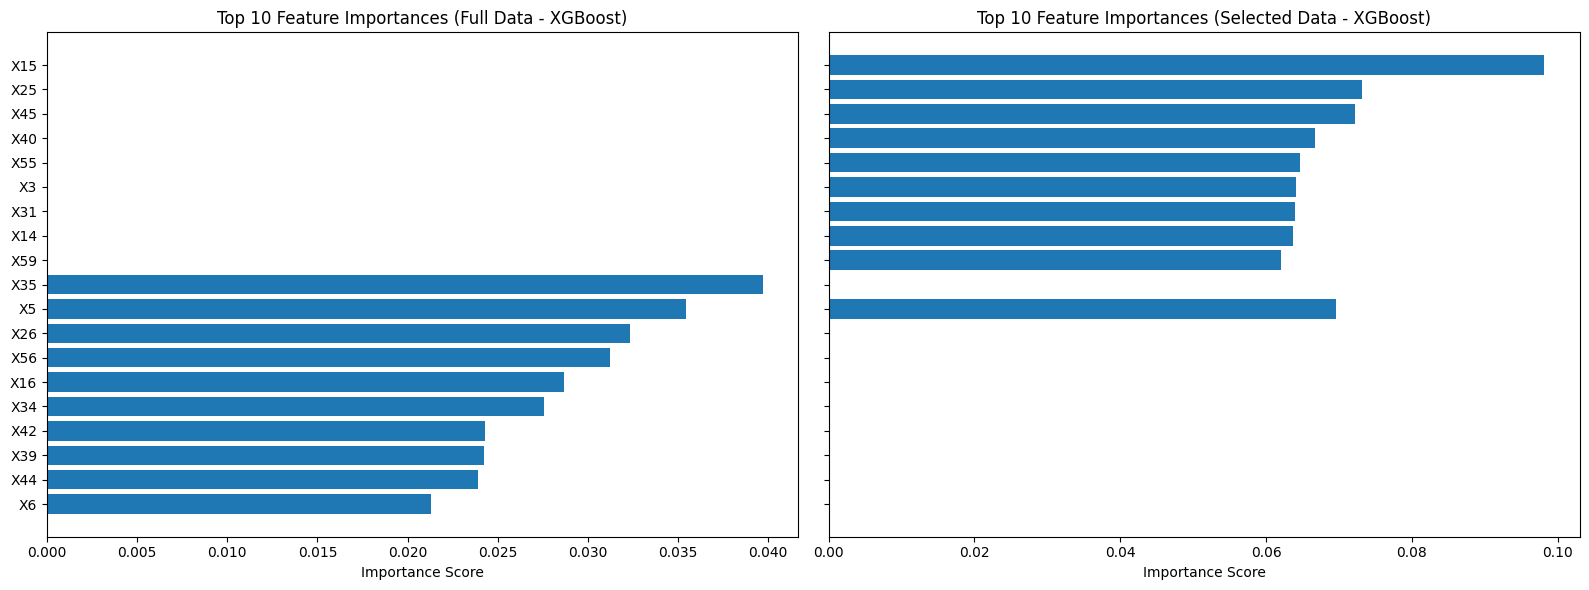

In [39]:
# Get feature importances
importances_full = model_xgb.feature_importances_
features_full = X_train.columns

importances_selected = model_xgb_selected.feature_importances_
features_selected = X_selected_train.columns

# Create DataFrames
importance_df_full = pd.DataFrame({'Feature': features_full, 'Importance': importances_full})
importance_df_full.sort_values(by='Importance', ascending=False, inplace=True)

importance_df_selected = pd.DataFrame({'Feature': features_selected, 'Importance': importances_selected})
importance_df_selected.sort_values(by='Importance', ascending=False, inplace=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Full feature importance
axes[0].barh(
    importance_df_full['Feature'].iloc[:10][::-1],
    importance_df_full['Importance'].iloc[:10][::-1]
)
axes[0].set_title("Top 10 Feature Importances (Full Data - XGBoost)")
axes[0].set_xlabel("Importance Score")

# Selected feature importance
axes[1].barh(
    importance_df_selected['Feature'].iloc[:10][::-1],
    importance_df_selected['Importance'].iloc[:10][::-1]
)
axes[1].set_title("Top 10 Feature Importances (Selected Data - XGBoost)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

### Comparative ROC between RF and XGBoost
- We have 4 models and now we will compare accuracy score and AUC score

#### 4. Get prediction probabilities




In [40]:
y_RF_Full = model_rf_all.predict_proba(X_test)[:, 1]
y_RF_sel = model_rf_selected.predict_proba(X_selected_test)[:, 1]
y_XGB_Full = model_xgb.predict_proba(X_test)[:, 1]
y_XGB_sel = model_xgb_selected.predict_proba(X_selected_test)[:, 1]

In [53]:
ypred_all = pd.DataFrame([y_RF_Full,y_RF_sel,y_XGB_Full,y_XGB_sel]).T

In [55]:
ypred_all.columns = ["RF_Full","RF_Selected","XGB_Full","XGB_Selected"]

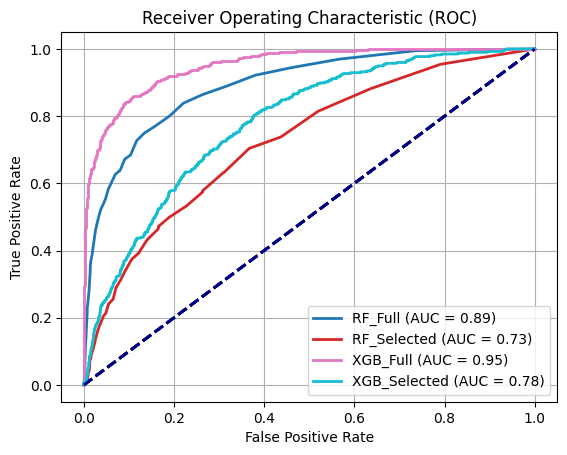

In [65]:
plt.figure()
colors = plt.cm.tab10(np.linspace(0, 1, len(ypred_all.columns)))

for i,yi in enumerate(ypred_all.columns):

    fpr, tpr, thresholds = roc_curve(y_test, ypred_all[yi])
    roc_auc = auc(fpr, tpr)   
    
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{yi} (AUC = {roc_auc:.2f})')    
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.grid(True)
plt.show()

### 5. Classification report

In [71]:
y_pred_rf_full = model_rf_all.predict(X_test)
y_pred_rf_sel  = model_rf_selected.predict(X_selected_test)
y_pred_xgb_full = model_xgb.predict(X_test)
y_pred_xgb_sel  = model_xgb_selected.predict(X_selected_test)



In [79]:
report_rf_full = classification_report(y_test,y_pred_rf_full,output_dict=True)
report_rf_sel  = classification_report(y_test,y_pred_rf_sel,output_dict=True)
report_xgb_full = classification_report(y_test,y_pred_xgb_full,output_dict=True)
report_xgb_sel  = classification_report(y_test,y_pred_xgb_sel,output_dict=True)

In [83]:
print(classification_report(y_test,y_pred_rf_full))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      8285
         1.0       0.56      0.07      0.12       396

    accuracy                           0.96      8681
   macro avg       0.76      0.53      0.55      8681
weighted avg       0.94      0.96      0.94      8681



In [84]:
print(classification_report(y_test,y_pred_xgb_full))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      8285
         1.0       0.89      0.36      0.52       396

    accuracy                           0.97      8681
   macro avg       0.93      0.68      0.75      8681
weighted avg       0.97      0.97      0.96      8681



In [85]:
print(classification_report(y_test,y_pred_rf_sel))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      8285
         1.0       0.05      0.01      0.01       396

    accuracy                           0.95      8681
   macro avg       0.50      0.50      0.49      8681
weighted avg       0.91      0.95      0.93      8681



In [87]:
print(classification_report(y_test,y_pred_xgb_sel))

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      8285
         1.0       0.17      0.03      0.05       396

    accuracy                           0.95      8681
   macro avg       0.56      0.51      0.51      8681
weighted avg       0.92      0.95      0.93      8681

